# Training on INCLUDE_50 Dataset

## Preprocessing Data

In [9]:
import pandas as pd
import numpy as np
import os
from glob import glob

import tensorflow as tf
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, Flatten, TimeDistributed, Reshape
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split

from tqdm.notebook import tqdm

In [10]:
# Checking whether the gpu is available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        print("Using GPU:", gpus)

    except RuntimeError as e:
        print(e)

else:
    print("No GPU found.")

Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [11]:
# First removing the path by split and then splitting the string to get the label
# input_path = [i for i in glob('Dataset\*\*\*.mp4')]
input_path = [i for i in glob('MP_Data\*\*.npy')]
output_label = [i.split("\\")[-1] for i in glob('MP_data\*')] 

print(output_label)
# input_path

['Bank', 'big large', 'Bird', 'Black', 'Boy', 'Brother', 'Car', 'Cell phone', 'Court', 'Cow', 'Death', 'Dog', 'dry', 'Election', 'Fall', 'Fan', 'Father', 'Girl', 'good', 'Good Morning', 'happy', 'Hat', 'Hello', 'hot', 'House', 'I', 'it', 'long', 'loud', 'Monday', 'new', 'Paint', 'Pen', 'Priest', 'quiet', 'Red', 'Shoes', 'short', 'small little', 'Store or Shop', 'Summer', 'T-Shirt', 'Teacher', 'Thank you', 'Time', 'train ticket', 'White', 'Window', 'Year', 'you (plural)']


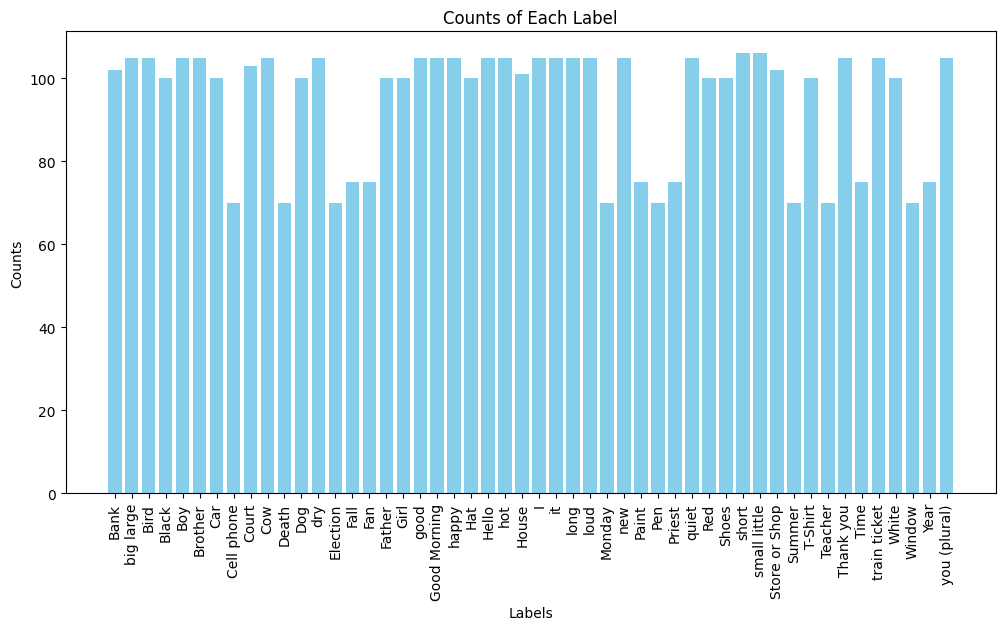

In [12]:
import matplotlib.pyplot as plt

# Count the occurrences of each label in y
label_counts = [len(os.listdir(i)) for i in glob('MP_data\*')]

# Create a bar graph
plt.figure(figsize=(12, 6))
plt.bar(output_label, label_counts, color='skyblue')
plt.xlabel('Labels')
plt.ylabel('Counts')
plt.title('Counts of Each Label')
plt.xticks(rotation=90)
plt.show()

In [13]:
labels = pd.Series(output_label).unique()
labels = pd.Series(labels).to_list()

train_path = pd.Series(input_path)

train_path.sample(5),len(labels)

(4617     MP_Data\Year\MVI_9177_downsampled.npy
 4387    MP_Data\White\MVI_3744_downsampled.npy
 3270      MP_Data\quiet\MVI_5338_upsampled.npy
 3328    MP_Data\quiet\MVI_9537_downsampled.npy
 2772        MP_Data\loud\MVI_5336_centered.npy
 dtype: object,
 50)

In [14]:
label_map = dict()

for i in range(len(labels)):
    for j in input_path:
        sep = j.split("\\")
        cur_label  = sep[-2].split(" ")[-1]
    label_map[i] = labels[i]
            
label_map    

{0: 'Bank',
 1: 'big large',
 2: 'Bird',
 3: 'Black',
 4: 'Boy',
 5: 'Brother',
 6: 'Car',
 7: 'Cell phone',
 8: 'Court',
 9: 'Cow',
 10: 'Death',
 11: 'Dog',
 12: 'dry',
 13: 'Election',
 14: 'Fall',
 15: 'Fan',
 16: 'Father',
 17: 'Girl',
 18: 'good',
 19: 'Good Morning',
 20: 'happy',
 21: 'Hat',
 22: 'Hello',
 23: 'hot',
 24: 'House',
 25: 'I',
 26: 'it',
 27: 'long',
 28: 'loud',
 29: 'Monday',
 30: 'new',
 31: 'Paint',
 32: 'Pen',
 33: 'Priest',
 34: 'quiet',
 35: 'Red',
 36: 'Shoes',
 37: 'short',
 38: 'small little',
 39: 'Store or Shop',
 40: 'Summer',
 41: 'T-Shirt',
 42: 'Teacher',
 43: 'Thank you',
 44: 'Time',
 45: 'train ticket',
 46: 'White',
 47: 'Window',
 48: 'Year',
 49: 'you (plural)'}

In [ ]:
# Loading all the labeled videos in the dataset
X = []
y = []

for label in tqdm(labels):
    label_videos = os.listdir("MP_data/"+label) 
    
    for video in label_videos:        
        res = np.load("MP_data/" + f"{label}/" + video,allow_pickle=True)
    
        X.append(res)
        y.append(labels.index(label))      
        # print(y)

len(X),len(y)

  0%|          | 0/50 [00:00<?, ?it/s]

(74, 258)
(74, 1662)
(74, 1662)
(74, 1662)
(74, 1662)
(63, 258)
(63, 1662)
(63, 1662)
(63, 1662)
(63, 1662)
(62, 258)
(62, 1662)
(62, 1662)
(62, 1662)
(62, 1662)
(63, 258)
(63, 1662)
(63, 1662)
(63, 1662)
(63, 1662)
(63, 1662)
(82, 258)
(82, 1662)
(82, 1662)
(82, 1662)
(82, 1662)
(66, 1662)
(59, 258)
(59, 1662)
(59, 1662)
(59, 1662)
(59, 1662)
(59, 258)
(59, 1662)
(59, 1662)
(59, 1662)
(59, 1662)
(70, 258)
(70, 1662)
(70, 1662)
(70, 1662)
(70, 1662)
(44, 258)
(44, 1662)
(44, 1662)
(44, 1662)
(44, 1662)
(41, 258)
(41, 1662)
(41, 1662)
(41, 1662)
(41, 1662)
(48, 258)
(48, 1662)
(48, 1662)
(48, 1662)
(48, 1662)
(45, 258)
(45, 1662)
(45, 1662)
(45, 1662)
(45, 1662)
(50, 258)
(50, 1662)
(50, 1662)
(50, 1662)
(50, 1662)
(51, 258)
(51, 1662)
(51, 1662)
(51, 1662)
(51, 1662)
(45, 258)
(45, 1662)
(45, 1662)


KeyboardInterrupt: 

In [23]:
for i in X:
    print(len(i[0]))

258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
1662
258
1662
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
1662
1662
1662
1662
258
16

In [20]:
# Bhai yha meine kya hi harkat kari thi gandi wali bhai agar meine har vedio ka input ek baar mein hi pahucha dunga toh kaise kaam banega sab vedio ke inputs ko alag lena hoga na bhai :))))))

# Padding the videos to make them of the same length

max_frames = max([len(video) for video in X])
print(f"Max frames: {max_frames}")

X = pad_sequences(X, maxlen=max_frames, padding='post', dtype='float32')

print(X.shape)


Max frames: 154


ValueError: Shape of sample (1662,) of sequence at position 1 is different from expected shape (258,)

In [ ]:
X= np.array(X)
y= np.array(y)
# X= tf.convert_to_tensor(X)
# y= tf.convert_to_tensor(y)
y = to_categorical(y)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True) 

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)


X_train shape: (3588, 154, 1662)
X_val shape: (897, 154, 1662)
y_train shape: (3588, 50)
y_val shape: (897, 50)


# Model

## Architecture

In [ ]:
import keras

# input_shape = (79, 1662)
input_shape = X_train[0].shape #(79, 1662)
num_classes =  len(label_map.keys())#50
input_shape,num_classes

((154, 1662), 50)

In [10]:


INCLUDE8_V2 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(128, activation='relu'),
        
        # Output layer
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V2

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 79, 128)        │       884,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 79, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 79, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 79, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10112)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,294,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,476,168 (9.45 MB)

 Trainable params: 2,476,168 (9.45 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:

INCLUDE8_V3 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(128, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V3

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirectiona  (None, 154, 128)         884224    
 l)                                                              
                                                                 
 bidirectional_1 (Bidirectio  (None, 154, 256)         263168    
 nal)                                                            
                                                                 
 bidirectional_2 (Bidirectio  (None, 154, 128)         164352    
 nal)                                                            
                                                                 
 flatten (Flatten)           (None, 19712)             0         
                                                                 
 dense (Dense)               (None, 128)               2523264   
                                                        

In [12]:

INCLUDE8_V4 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(128, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V3

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 79, 128)        │       884,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 79, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 79, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10112)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,294,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,607,240 (9.95 MB)

 Trainable params: 2,607,240 (9.95 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train, y_train,
          validation_data=(X_val, y_val),
          epochs=100,
          callbacks=[early_stop])

Epoch 1/100
113/113 [==============================] - 28s 122ms/step - loss: 3.7903 - accuracy: 0.0404 - val_loss: 3.6566 - val_accuracy: 0.0479
Epoch 2/100
113/113 [==============================] - 11s 97ms/step - loss: 3.5822 - accuracy: 0.0630 - val_loss: 3.5008 - val_accuracy: 0.0881
Epoch 3/100
113/113 [==============================] - 11s 101ms/step - loss: 3.1984 - accuracy: 0.1363 - val_loss: 3.1621 - val_accuracy: 0.1315
Epoch 4/100
113/113 [==============================] - 12s 103ms/step - loss: 2.6731 - accuracy: 0.2369 - val_loss: 2.5090 - val_accuracy: 0.2832
Epoch 5/100
113/113 [==============================] - 11s 101ms/step - loss: 2.2201 - accuracy: 0.3542 - val_loss: 2.0729 - val_accuracy: 0.3902
Epoch 6/100
113/113 [==============================] - 12s 105ms/step - loss: 1.7727 - accuracy: 0.4830 - val_loss: 1.7662 - val_accuracy: 0.4849
Epoch 7/100
113/113 [==============================] - 11s 102ms/step - loss: 1.3118 - accuracy: 0.6179 - val_loss: 1.5429 - 

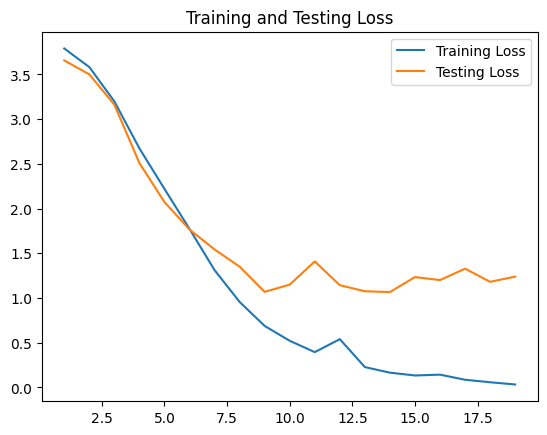

<Figure size 640x480 with 0 Axes>

In [13]:
from matplotlib import pyplot as plt

train_loss = history.history['loss']
eval_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.plot(epochs,train_loss,label = "Training Loss")
plt.plot(epochs,eval_loss,label = "Testing Loss")

plt.title("Training and Testing Loss")
plt.legend()
plt.figure()
plt.show();

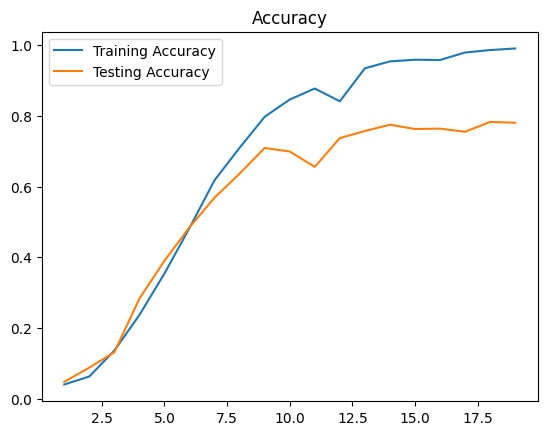

<Figure size 640x480 with 0 Axes>

In [14]:
train_acc = history.history['accuracy']
eval_acc = history.history['val_accuracy']
epochs = range(1, len(train_loss) + 1)
plt.plot(epochs,train_acc,label = "Training Accuracy")
plt.plot(epochs,eval_acc,label = "Testing Accuracy")

plt.title("Accuracy")
plt.legend()
plt.figure()
plt.show();

In [22]:
# Predict probabilities for the test data
probabilities = model.predict(X_val)

# Convert probabilities to class labels
predicted_classes = np.argmax(probabilities, axis=-1)

total = len(X_val)
pred = 0
for i in range(total):
   if (label_map[predicted_classes[i]]) == (label_map[np.argmax(y_val[i])]):
         pred += 1

acc = (pred/total)*100

acc, total,pred

29/29 [==============================] - 1s 46ms/step


(77.48049052396878, 897, 695)

In [ ]:
# model.save('INCLUDE_8_V1.h5')
try:
    os.mkdir("Model")
except:
    pass

model.save("Model\INCLUDE_50_V3.h5")